<a href="https://colab.research.google.com/github/Maleewij65/heart-disease-prediction-ML_Assignment/blob/IT22325778_SVM/svm_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Support Vector Machine (SVM) Model


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, learning_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_curve, auc
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import warnings

warnings.filterwarnings("ignore")

In [3]:
data = pd.read_csv('/content/heart.csv')
data = data[data['Cholesterol'] > 0]

print(data.shape)
data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/heart.csv'

In [4]:
from google.colab import files
import os

# Check if the file already exists to avoid re-uploading
if not os.path.exists('/content/heart.csv'):
  print('Please upload the heart.csv file:')
  uploaded = files.upload()
  for fn in uploaded.keys():
    print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')
else:
  print('heart.csv already exists in /content/. Skipping upload.')

Please upload the heart.csv file:


Saving heart.csv to heart.csv
User uploaded file "heart.csv" with length 35921 bytes


In [5]:
import pandas as pd

data = pd.read_csv('/content/heart.csv')
data = data[data['Cholesterol'] > 0]

print(data.shape)
display(data.head())

(746, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
numerical_cols = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

X = data.drop('HeartDisease', axis=1)
y = data['HeartDisease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (596, 11)
Testing set shape: (150, 11)


In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ]
)

svm_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SVC(probability=True, random_state=42))
])

In [8]:
param_grid = {
    'classifier__C': [0.1, 1, 10, 100],
    'classifier__gamma': [0.01, 0.1, 1, 'scale'],
    'classifier__kernel': ['linear', 'rbf', 'poly']
}

grid = GridSearchCV(
    svm_pipeline,
    param_grid,
    cv=5,
    scoring='f1',
    verbose=1,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:", grid.best_params_)
print("Best cross-validation score:", grid.best_score_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best parameters: {'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'linear'}
Best cross-validation score: 0.856809753954798


In [9]:
best_svm = grid.best_estimator_

y_pred = best_svm.predict(X_test)
y_pred_proba = best_svm.predict_proba(X_test)[:, 1]

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8466666666666667
Precision: 0.8266666666666667
Recall: 0.8611111111111112
F1 Score: 0.8435374149659864

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.83      0.85        78
           1       0.83      0.86      0.84        72

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150



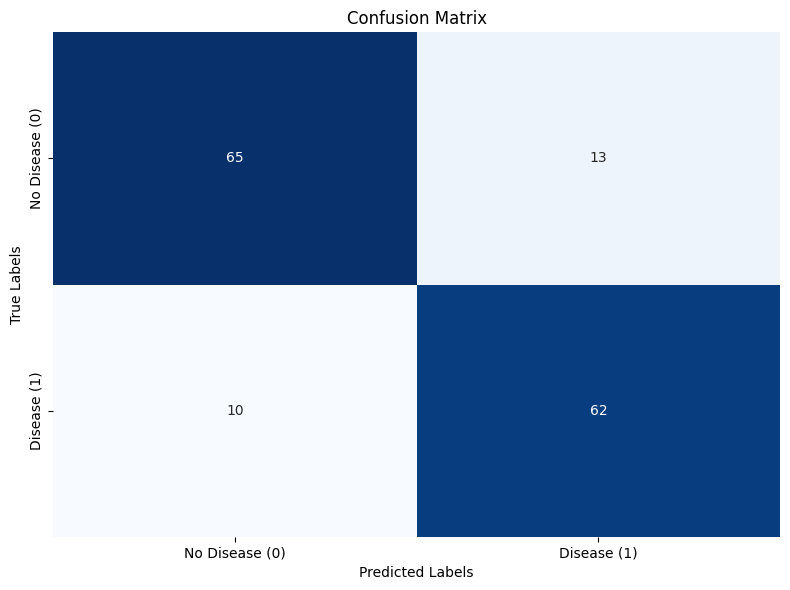

In [11]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.xticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'])
plt.yticks([0.5, 1.5], ['No Disease (0)', 'Disease (1)'])
plt.tight_layout()
plt.show()

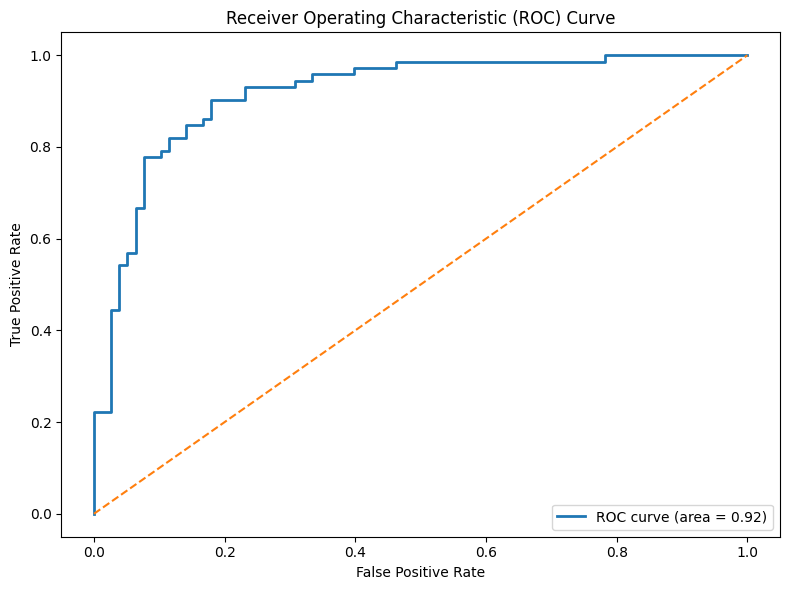

ROC AUC: 0.9179131054131054


In [12]:
plt.figure(figsize=(8, 6))
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print("ROC AUC:", roc_auc)

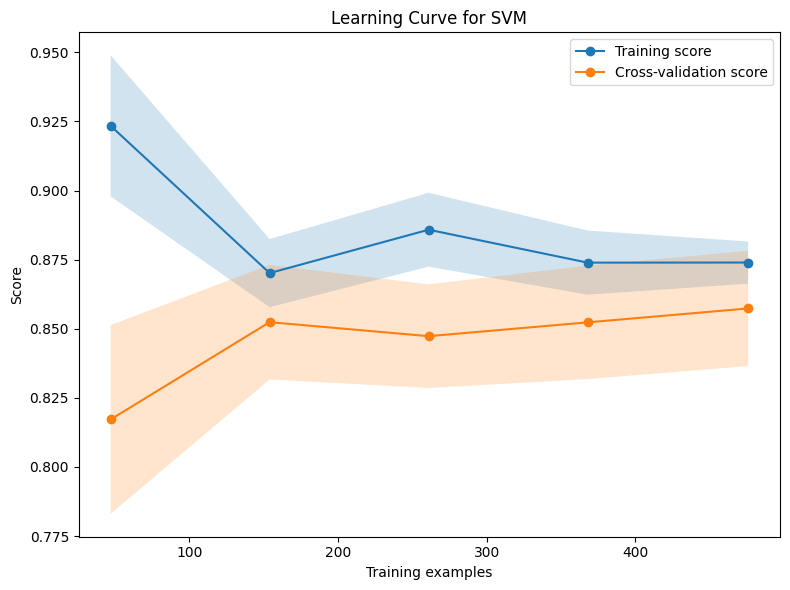

In [17]:
train_sizes, train_scores, val_scores = learning_curve(
    best_svm,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 5)
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(8, 6))
plt.plot(train_sizes, train_mean, 'o-', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)
plt.title("Learning Curve for SVM")
plt.xlabel("Training examples")
plt.ylabel("Score")
plt.legend(loc="best")
plt.tight_layout()
plt.show()

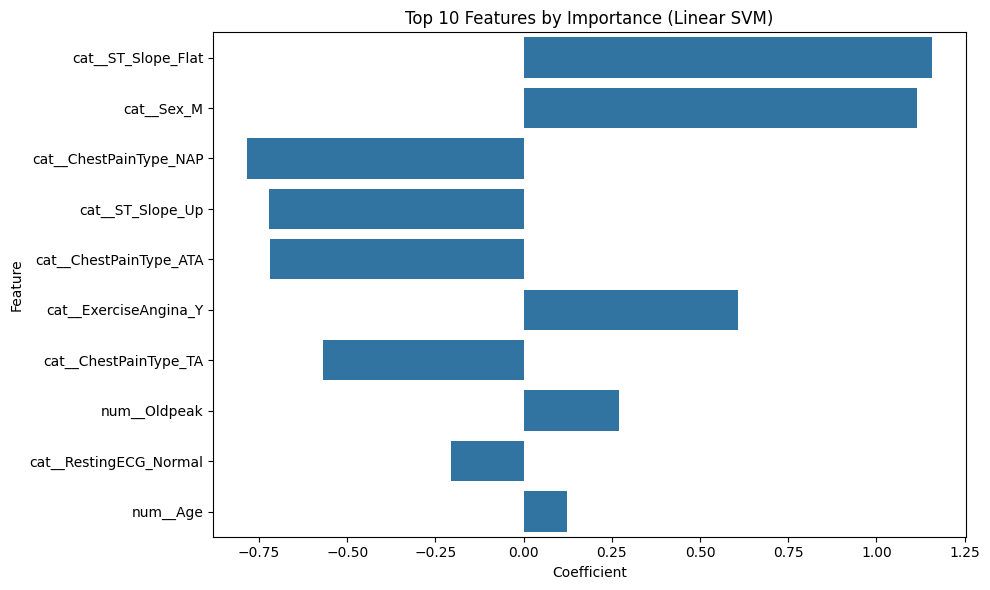

In [18]:
if best_svm.named_steps['classifier'].kernel == 'linear':
    feature_names = best_svm.named_steps['preprocessor'].get_feature_names_out()
    coefs = best_svm.named_steps['classifier'].coef_[0]

    feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Coefficient': coefs
    }).sort_values(by='Coefficient', key=abs, ascending=False).head(10)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feat_imp, x='Coefficient', y='Feature')
    plt.title('Top 10 Features by Importance (Linear SVM)')
    plt.tight_layout()
    plt.show()

In [20]:
print("\n--- Model Summary ---\n")
print("Best SVM Parameters:", grid.best_params_)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC AUC  : {roc_auc:.4f}")


--- Model Summary ---

Best SVM Parameters: {'classifier__C': 1, 'classifier__gamma': 0.01, 'classifier__kernel': 'linear'}
Accuracy : 0.8467
Precision: 0.8267
Recall   : 0.8611
F1 Score : 0.8435
ROC AUC  : 0.9179


In [22]:
from sklearn.model_selection import cross_val_score
import numpy as np

# model = your trained model (e.g., SVC(), LogisticRegression(), etc.)
# X = features, y = labels

scores = cross_val_score(best_svm, X, y, cv=5)

print("Cross-validation scores:", scores)
print("Mean accuracy:", np.mean(scores))
print("Standard deviation:", np.std(scores))

Cross-validation scores: [0.88666667 0.93959732 0.87919463 0.79865772 0.73154362]
Mean accuracy: 0.8471319910514541
Standard deviation: 0.07328201055977827


In [23]:
from sklearn.model_selection import cross_validate

scoring = ['accuracy', 'precision', 'recall', 'f1']

cv_results = cross_validate(best_svm, X, y, cv=5, scoring=scoring)

for metric in scoring:
    print(f"{metric}: {cv_results['test_' + metric].mean():.4f}")

accuracy: 0.8471
precision: 0.8295
recall: 0.8567
f1: 0.8415


In [24]:
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
import numpy as np

# The best_svm is already defined from the GridSearchCV
# If you intend to use a different SVC model for cross-validation, define it here.
# For now, I will use the best_svm from the previous tuning.

scores = cross_val_score(best_svm, X, y, cv=5)

print("SVM CV Scores:", scores)
print("Mean:", scores.mean())
print("Std:", scores.std())

SVM CV Scores: [0.88666667 0.93959732 0.87919463 0.79865772 0.73154362]
Mean: 0.8471319910514541
Std: 0.07328201055977827
